# Market Analysis Project

In this notebook we analyze the S&P 500 using Python.

Steps:
1. Download stock data
2. Clean missing values
3. Calculate returns and volatility
4. Study correlations
5. Create a 2D map of the market using PCA

The goal is to understand how stocks move together and visualize the structure of the market.

In [1]:
# Apply a visual "Quant" style
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio

plt.style.use('dark_background')
sns.set_context("talk")
custom_params = {
    "axes.spines.right": False,
    "axes.spines.top": False,
    "grid.alpha": 0.1
}
sns.set_theme(style="darkgrid", rc=custom_params)

pio.templates.default = "plotly_dark"

# Step 1: Downloading Data

Here I download 5 years of price data for all S&P 500 stocks using yfinance.

I use adjusted prices so the data accounts for stock splits and dividends.

In [2]:
import pandas as pd
import yfinance as yf
import requests
from datetime import datetime, timedelta

# 1. Retrieve S&P 500 Tickers from Wikipedia
print("Fetching S&P 500 ticker list...")
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)
table = pd.read_html(response.text)
sp500_df = table[0]
tickers = sp500_df['Symbol'].tolist()

# Yahoo Finance uses '-' instead of '.' for tickers like BRK.B
tickers = [t.replace('.', '-') for t in tickers]

print(f"Retrieved {len(tickers)} tickers.")

# 2. Download 5 years of historical data (Adjusted Close)
end_date = datetime.now()
start_date = end_date - timedelta(days=5*365)

print("Downloading price data (this may take a few minutes)...")
raw_data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    interval='1d'
, group_by="ticker", auto_adjust=True)

print("Download complete.")

/Users/daphne/Desktop/quant_market_map/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Fetching S&P 500 ticker list...


/var/folders/gt/gf9mfwm14m9g9tmprjhzcvc80000gn/T/ipykernel_7137/2270472086.py:15: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_html(response.text)


Retrieved 503 tickers.


[*********************100%***********************]  503 of 503 completed


Download complete.


In [3]:
# Extract adjusted close prices from the multi-index dataframe
clean_prices = pd.DataFrame({
    ticker: raw_data[ticker]['Close']
    for ticker in raw_data.columns.levels[0]
})


In [4]:
clean_prices.shape
clean_prices.head()

,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2021-02-10,120.883690,131.992645,85.930626,211.660004,114.351936,33.176849,239.974457,492.670013,140.415771,47.708267,...,28.121017,113.178368,53.142071,42.490425,95.421799,257.489990,95.493805,149.431763,427.470001,153.145172
2021-02-11,122.700630,131.739182,85.682861,216.839996,115.766602,33.813953,241.870407,496.619995,145.519989,48.111237,...,27.998400,111.370453,52.536251,41.426510,93.346184,265.929993,96.555656,151.174561,470.079987,156.787430
2021-02-12,123.686401,131.973145,86.252716,212.679993,117.035233,33.424084,240.469437,498.839996,147.334366,48.812065,...,28.644201,114.548859,52.510654,41.991718,93.516006,272.750000,96.546501,150.401016,477.739990,158.951797
2021-02-16,123.657387,129.847931,86.054497,209.860001,116.843605,33.195866,240.077148,501.640015,147.068634,49.101143,...,28.521585,118.018852,51.631771,43.255127,93.383911,276.019989,96.665504,149.459778,486.010010,158.579941
2021-02-17,125.754616,127.556808,87.780563,201.960007,116.131653,33.614262,241.692917,491.230011,146.390549,48.987263,...,27.924826,118.747864,51.964554,43.928387,92.901382,270.940002,95.512108,147.791519,479.579987,161.039856


## Step 2: Checking Missing Data

This heatmap shows where stock data is missing.

We remove stocks with too many missing values and fill small gaps so the dataset is usable.

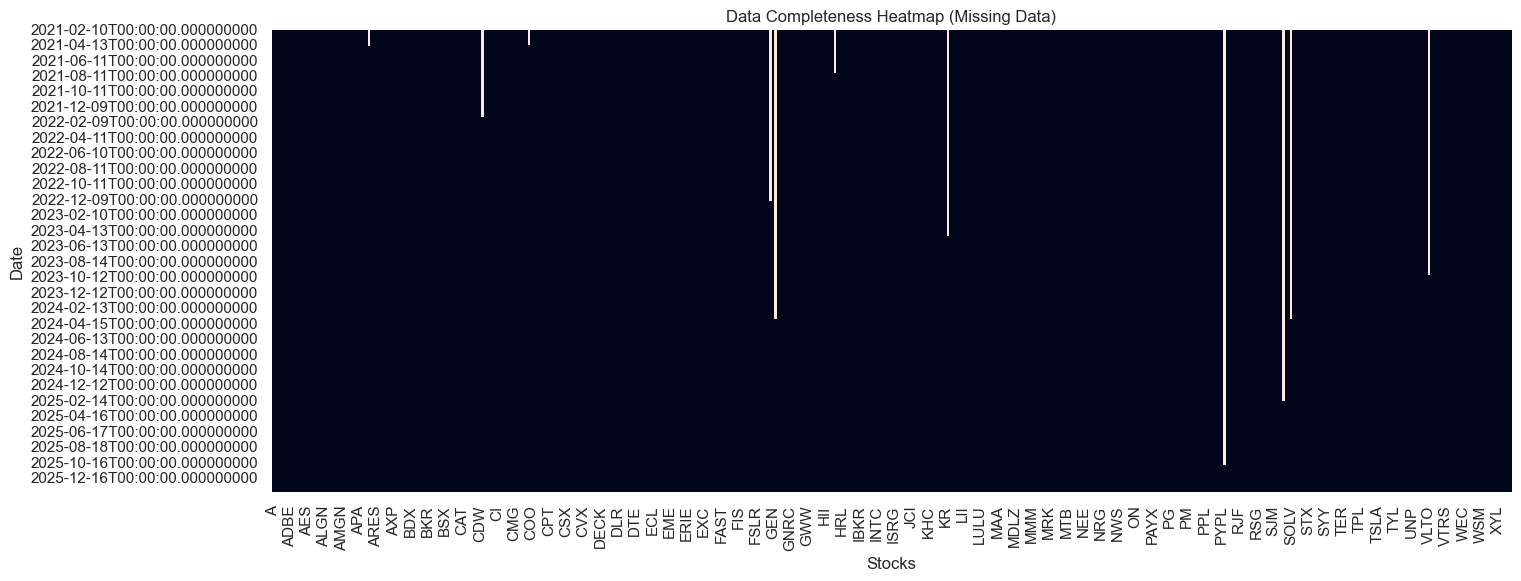

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 6))
sns.heatmap(clean_prices.isna(), cbar=False)
plt.title("Data Completeness Heatmap (Missing Data)")
plt.xlabel("Stocks")
plt.ylabel("Date")
plt.show()

In [6]:
# Drop stocks missing more than 10% of their data
threshold = int(0.9 * len(clean_prices))
clean_prices = clean_prices.dropna(axis=1, thresh=threshold)

# Forward-fill small gaps
clean_prices = clean_prices.fillna(method="ffill")

clean_prices.shape

/var/folders/gt/gf9mfwm14m9g9tmprjhzcvc80000gn/T/ipykernel_7137/3092663526.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  clean_prices = clean_prices.fillna(method="ffill")


(1254, 495)

# Step 3: Returns and Volatility

Stock prices are converted into daily returns so they can be compared properly.

We also calculate rolling volatility to see how risky the market is over time.

In [7]:
# Daily percentage returns
returns = clean_prices.pct_change().dropna()

returns.head()

,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2021-07-30,0.003668,0.001511,-0.021620,0.003764,-0.000908,0.012987,-0.002105,-0.000113,0.005284,0.002014,...,-0.031582,-0.014335,-0.007850,-0.023078,0.006317,-0.031417,0.008288,0.004178,0.007991,-0.006957
2021-08-02,-0.001044,-0.002331,-0.007309,0.010277,-0.000496,0.005385,-0.005037,-0.004633,0.001195,-0.006028,...,0.014527,0.000407,0.004542,0.000174,-0.001669,0.101594,0.007611,-0.002509,-0.002733,-0.002911
2021-08-03,0.005161,0.012644,0.006930,0.001100,0.009924,0.003316,0.007720,0.004089,0.006324,0.007244,...,0.009351,-0.033445,0.002042,0.010768,0.018227,-0.010610,0.007780,-0.057052,-0.007677,0.009846
2021-08-04,0.002665,-0.002782,-0.010065,0.012015,-0.004504,0.002033,-0.005494,0.007082,0.023121,-0.017395,...,-0.014476,-0.041965,0.003639,-0.023368,-0.009927,-0.011392,0.000750,-0.035652,0.024253,0.003381
2021-08-05,0.004991,0.000748,0.000347,0.019810,0.005264,0.014460,0.011175,0.010229,-0.015355,0.000851,...,0.012926,0.083324,0.004206,0.006334,0.006790,0.057766,0.000899,0.013088,0.016464,-0.004639


In [8]:
clean_prices.shape


(1254, 495)

In [9]:
returns.shape

(1136, 495)

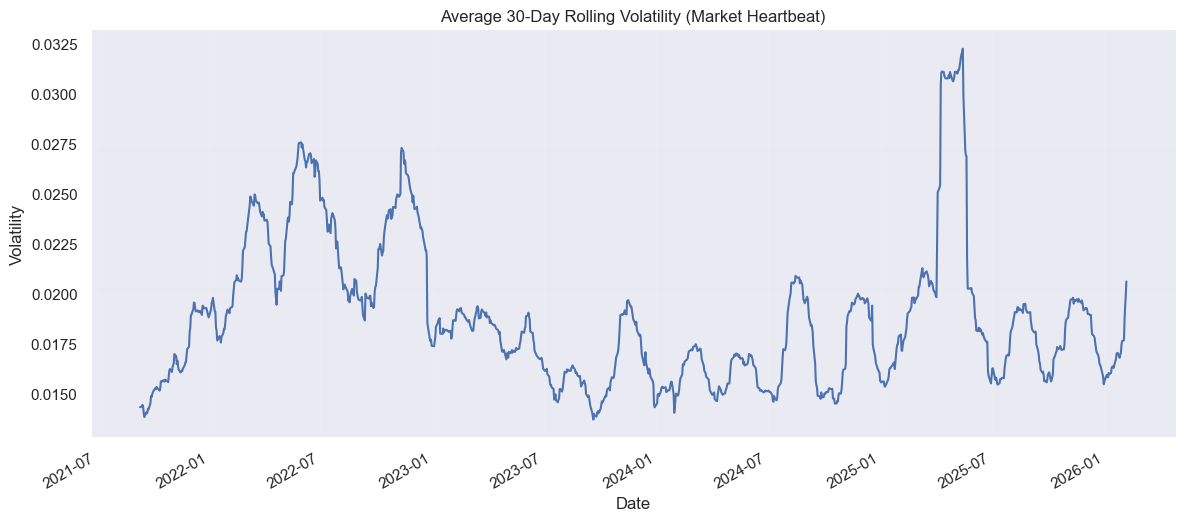

In [10]:
# 30-day rolling volatility
rolling_vol = returns.rolling(window=30).std()

plt.figure(figsize=(14,6))
rolling_vol.mean(axis=1).plot()
plt.title("Average 30-Day Rolling Volatility (Market Heartbeat)")
plt.ylabel("Volatility")
plt.show()

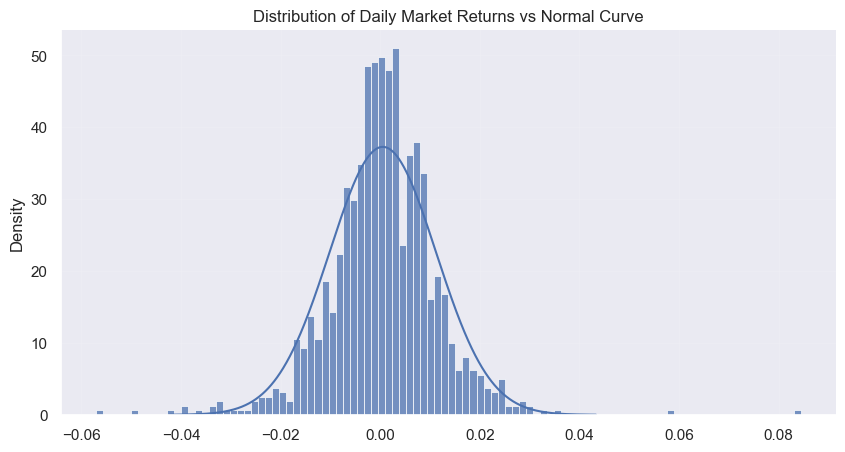

In [11]:
import numpy as np
from scipy.stats import norm

# average market return each day (like a mini S&P500 index)
market_returns = returns.mean(axis=1)

mu = market_returns.mean()
sigma = market_returns.std()

plt.figure(figsize=(10,5))
sns.histplot(market_returns, bins=100, stat="density")

# normal distribution curve
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
plt.plot(x, norm.pdf(x, mu, sigma))

plt.title("Distribution of Daily Market Returns vs Normal Curve")
plt.show()

In [12]:
import plotly.graph_objects as go
import yfinance as yf

# download one stock for candlestick view
ticker = "NVDA"

data = yf.download(ticker, period="1y", interval="1d")

fig = go.Figure()

fig.add_trace(go.Candlestick(
    x=data.index,
    open=data['Open'],
    high=data['High'],
    low=data['Low'],
    close=data['Close'],
    name="Price"
))

fig.update_layout(
    title=f"{ticker} Candlestick Chart",
    xaxis_title="Date",
    yaxis_title="Price"
)
import plotly.io as pio
pio.renderers.default = "browser"
fig.show()

[*********************100%***********************]  1 of 1 completed


# Step 4: Correlation Between Stocks

This section measures how stocks move together.

Stocks with high correlation behave similarly.  
Clustering helps group similar stocks and reveal market structure.

In [13]:
# correlation matrix of stock returns
corr_matrix = returns.corr()

corr_matrix.shape

(495, 495)

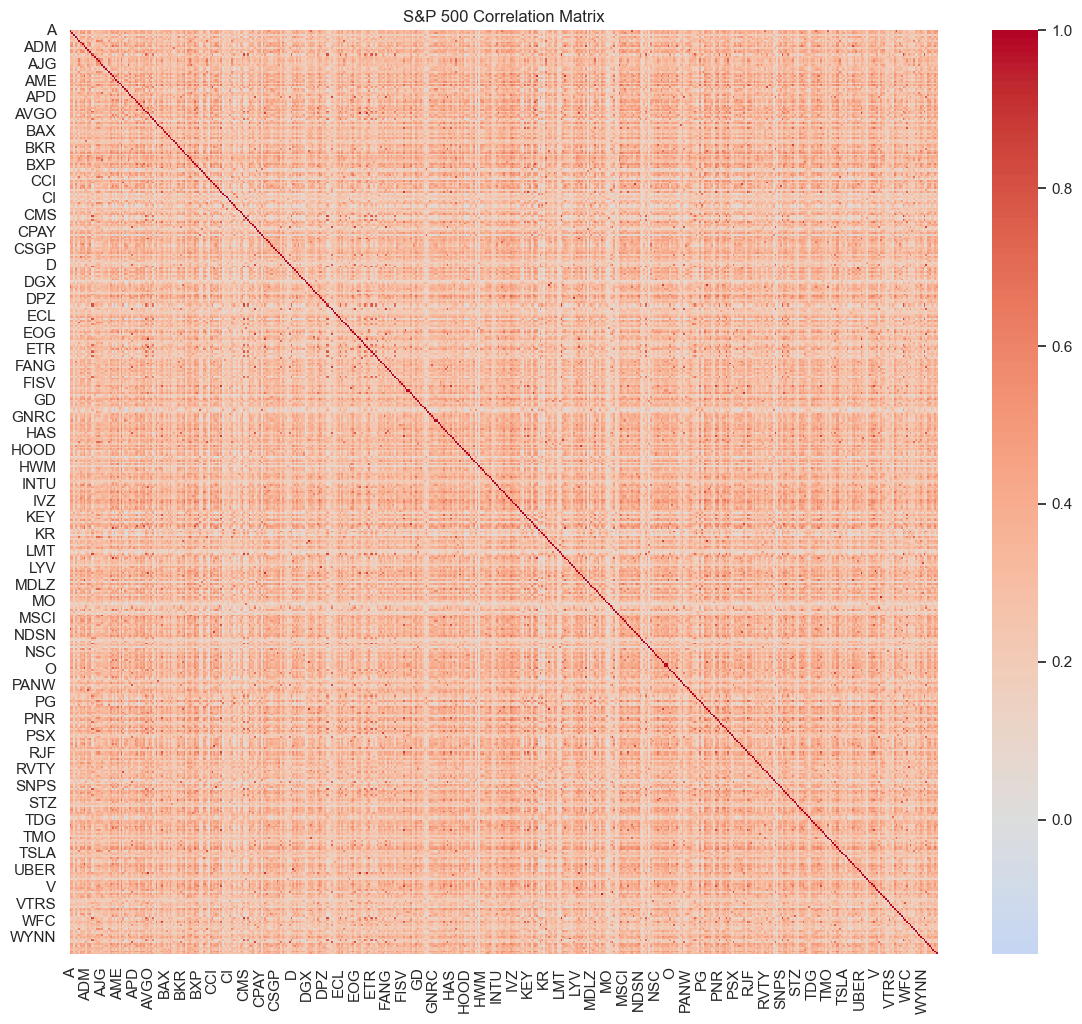

In [14]:
plt.figure(figsize=(14,12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("S&P 500 Correlation Matrix")
plt.show()

/Users/daphne/Desktop/quant_market_map/.venv/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning:

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.

/Users/daphne/Desktop/quant_market_map/.venv/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning:

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.



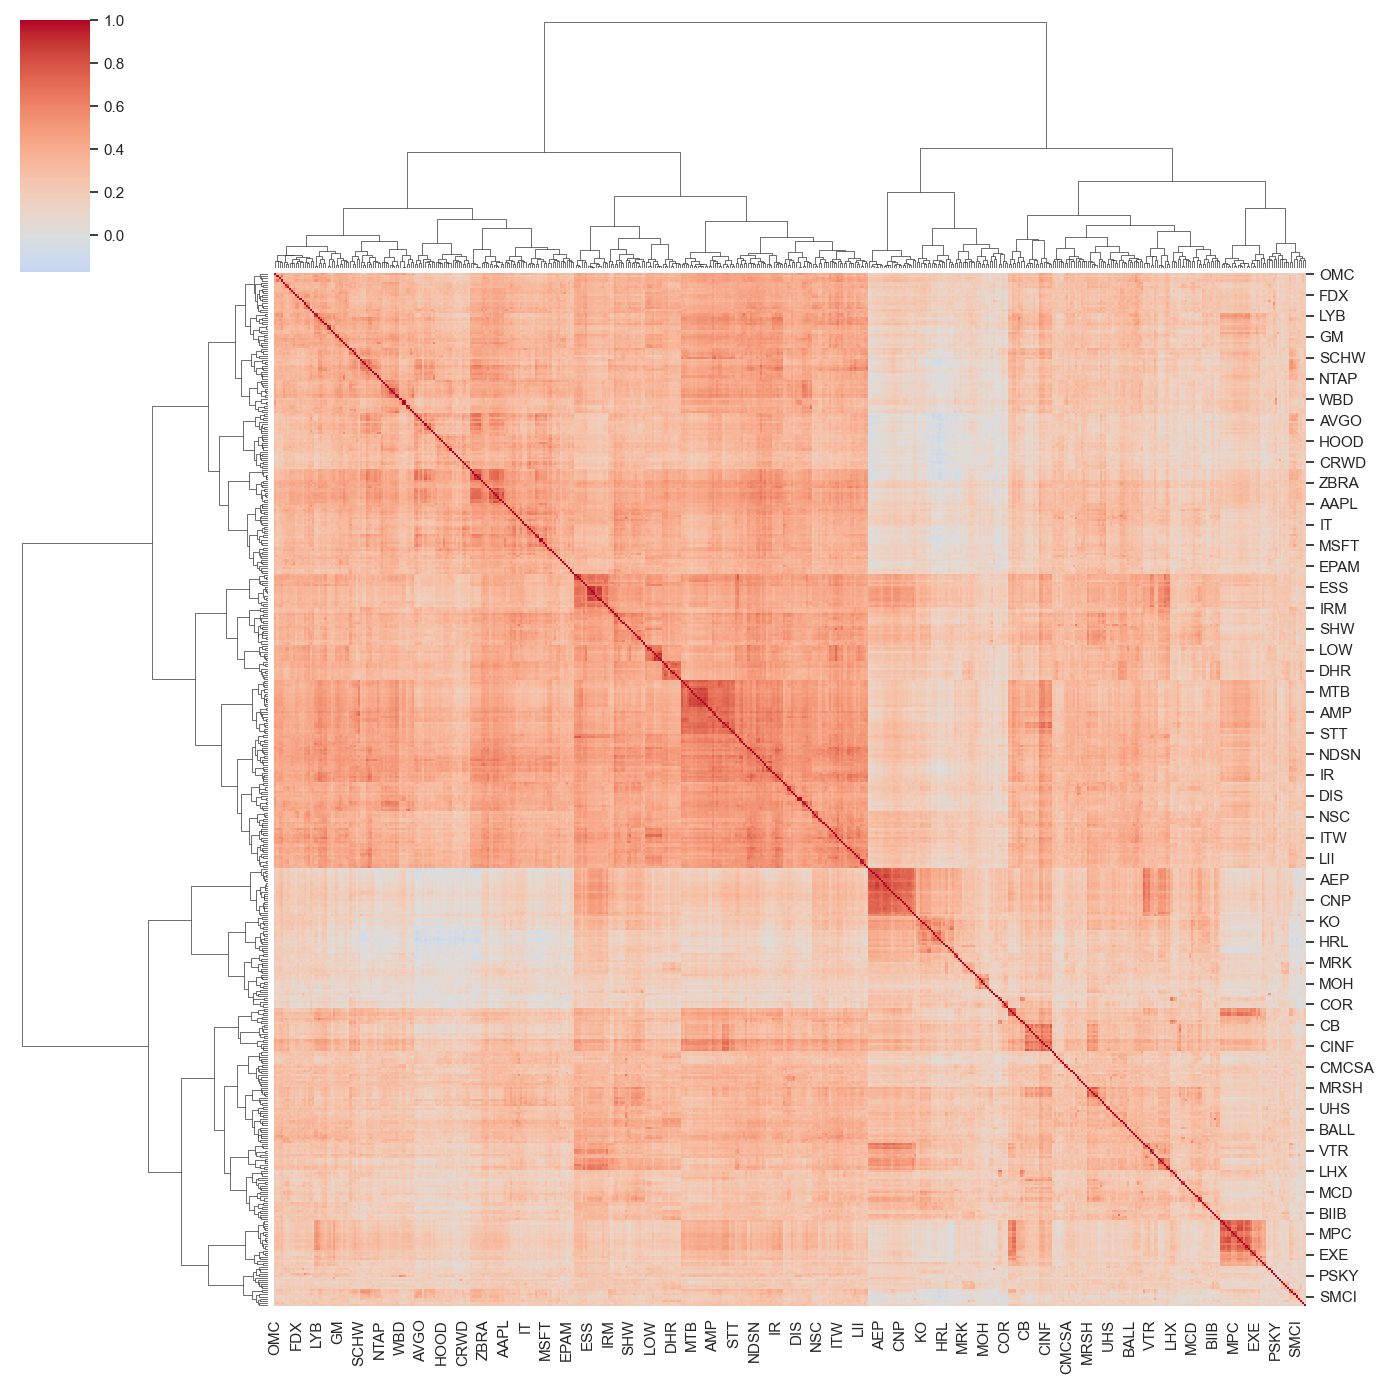

In [15]:
# hierarchical clustering clustermap
sns.clustermap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    figsize=(14,14),
    method="ward"
)

In [16]:
from sklearn.preprocessing import StandardScaler

# transpose so rows = stocks, columns = days
returns_T = returns.T

# normalize data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(returns_T)

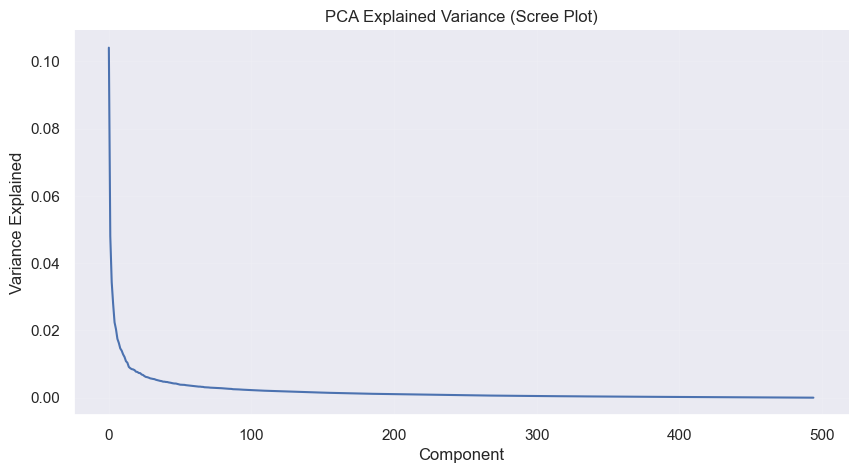

In [17]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(scaled_data)

explained = pca.explained_variance_ratio_

plt.figure(figsize=(10,5))
plt.plot(explained)
plt.title("PCA Explained Variance (Scree Plot)")
plt.xlabel("Component")
plt.ylabel("Variance Explained")
plt.show()

In [ ]:
from sklearn.manifold import TSNE
import numpy as np

# remove any NaN or infinite values
scaled_data_clean = np.nan_to_num(scaled_data)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    max_iter=1000   # new parameter name
)

tsne_results = tsne.fit_transform(scaled_data_clean)

/Users/daphne/Desktop/quant_market_map/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning:

divide by zero encountered in matmul

/Users/daphne/Desktop/quant_market_map/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning:

overflow encountered in matmul

/Users/daphne/Desktop/quant_market_map/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning:

invalid value encountered in matmul

/Users/daphne/Desktop/quant_market_map/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning:

divide by zero encountered in matmul

/Users/daphne/Desktop/quant_market_map/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning:

overflow encountered in matmul

/Users/daphne/Desktop/quant_market_map/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning:

invalid value encountered in matmul

/Users/daphne/Desktop/quant_market_map/.venv/lib/python3.9/site-pa

# Step 5: Market Map

PCA reduces the dataset into 2 dimensions so we can visualize the market.

Each dot represents a stock.  
Stocks close together behave similarly.  
Outliers behave differently from the rest.

/Users/daphne/Desktop/quant_market_map/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning:

divide by zero encountered in matmul

/Users/daphne/Desktop/quant_market_map/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning:

overflow encountered in matmul

/Users/daphne/Desktop/quant_market_map/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning:

invalid value encountered in matmul

/Users/daphne/Desktop/quant_market_map/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning:

divide by zero encountered in matmul

/Users/daphne/Desktop/quant_market_map/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning:

overflow encountered in matmul

/Users/daphne/Desktop/quant_market_map/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning:

invalid value encountered in matmul

/Users/daphne/Desktop/quant_market_map/.venv/lib/python3.9/site-pa

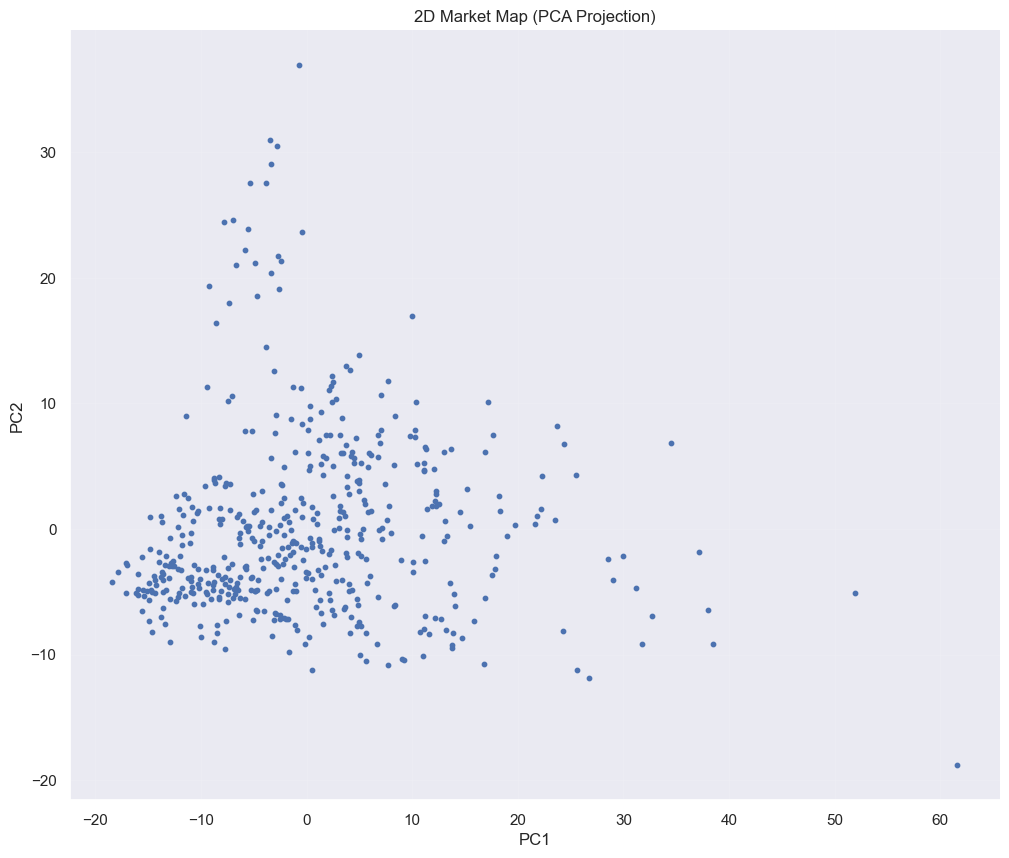

In [ ]:
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2)
pca_results = pca_2d.fit_transform(scaled_data)

plt.figure(figsize=(12,10))
plt.scatter(pca_results[:,0], pca_results[:,1], s=10)

plt.title("2D Market Map (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## Conclusion

In this notebook We:
- downloaded S&P 500 data  
- cleaned missing values  
- calculated returns and volatility  
- studied correlations  
- created a 2D market map  

This shows how quantitative tools can reveal hidden relationships between stocks.